## Initial baseline model

In [1]:
# Imports
import random
import os
import json
import re
from pathlib import Path
import tqdm
import cv2
from scipy import ndimage

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.preprocess import *


Processing: batch1_1.csv
Processing 499 images from ../finalproject_data/batch_1/batch1_1.csv
Images location: ../finalproject_data/batch_1/batch1_1


Processing batches: 100%|██████████| 10/10 [01:04<00:00,  6.45s/it]



Processing Complete!
Total images processed: 499
Successful: 499
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_2.csv
Processing 426 images from ../finalproject_data/batch_1/batch1_2.csv
Images location: ../finalproject_data/batch_1/batch1_2


Processing batches: 100%|██████████| 9/9 [00:54<00:00,  6.07s/it]



Processing Complete!
Total images processed: 426
Successful: 426
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

Processing: batch1_3.csv
Processing 489 images from ../finalproject_data/batch_1/batch1_3.csv
Images location: ../finalproject_data/batch_1/batch1_3


Processing batches: 100%|██████████| 10/10 [01:02<00:00,  6.30s/it]



Processing Complete!
Total images processed: 489
Successful: 489
Failed: 0
Processed images saved to: ../finalproject_data/processed_images

FINAL SUMMARY
Total images across all batches: 1414
Successfully processed: 1414
Failed: 0

Visualizing sample results...


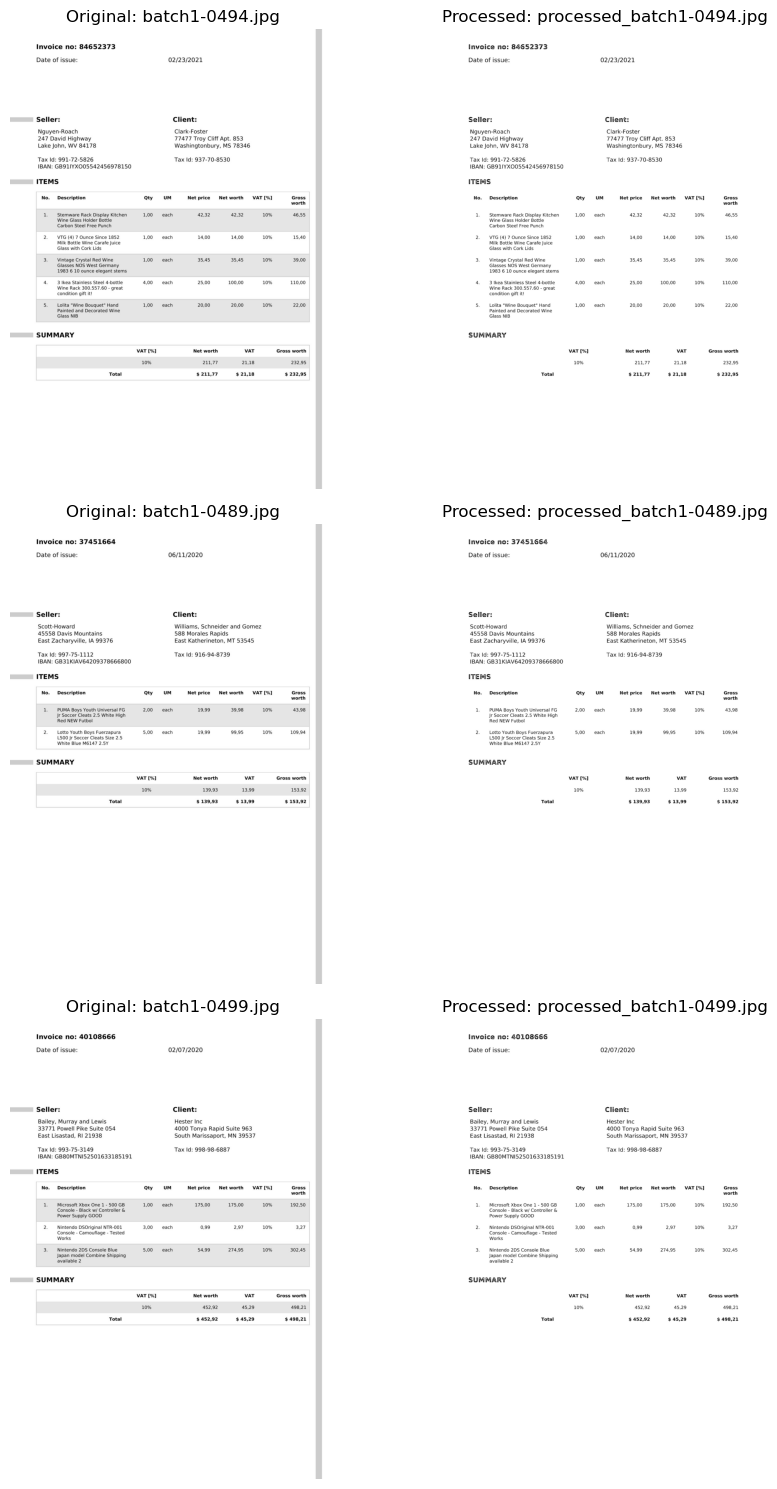

Processed images saved to: ../finalproject_data/processed_images


In [2]:
output_image_path = "../finalproject_data/processed_images"
csv_file_paths = [
    "../finalproject_data/batch_1/batch1_1.csv",
    "../finalproject_data/batch_1/batch1_2.csv",
    "../finalproject_data/batch_1/batch1_3.csv"
]

# Initialize preprocessor
preprocessor = InvoiceImagePreprocessor(output_dir=output_image_path)

image_folders = [
    '../finalproject_data/batch_1/batch1_1',
    '../finalproject_data/batch_1/batch1_2',
    '../finalproject_data/batch_1/batch1_3'
]

# Process all datasets
all_results = []
for csv_file, image_folder in zip(csv_file_paths, image_folders):
    print(f"\n{'='*80}")
    print(f"Processing: {Path(csv_file).name}")
    print(f"{'='*80}")
    
    results_df = preprocessor.process_images(csv_file, image_folder)
    all_results.append(results_df)

# Combine all results
if all_results:
    combined_results = pd.concat(all_results, ignore_index=True)
    
    print(f"\n{'='*80}")
    print("FINAL SUMMARY")
    print(f"{'='*80}")
    print(f"Total images across all batches: {len(combined_results)}")
    print(f"Successfully processed: {len(combined_results[combined_results['status'] == 'success'])}")
    print(f"Failed: {len(combined_results[combined_results['status'] == 'failed'])}")
    
    # Visualize sample results
    print("\nVisualizing sample results...")
    preprocessor.visualize_sample_results(combined_results)
    
    print(f"Processed images saved to: {output_image_path}")

In [4]:
# Rule-based extraction pipeline + evaluation
import random
try:
    import pytesseract
    TESSERACT_AVAILABLE = True
except Exception:
    TESSERACT_AVAILABLE = False

# Configuration
DATA_DIR = Path("../finalproject_data/batch_1")  
CSV_FILES = [
    DATA_DIR / "batch1_1.csv",
    DATA_DIR / "batch1_2.csv",
    DATA_DIR / "batch1_3.csv"
]
# sample size
N_SAMPLE = 100
RANDOM_SEED = 42
USE_TESSERACT = True   # If USE_TESSERACT True but pytesseract not available, will fall back to CSV OCRed Text